# eTOF time-of-flight → kinetic-energy calibration (config 1, Argon)

**Post-analysis task 1** (see `analysis/post/TASKS.md`).

## Objective
Map electron **time-of-flight (TOF, ns) → electron kinetic energy (KE, eV)**
for the config-1 electron TOF spectrometer, so every downstream electron
analysis (peak assignment, residual-gas background, covariance) can work
in kinetic energy.

## Data
| Role | Run | File | Notes |
|------|-----|------|-------|
| Argon calibration | 58826 | `argon_nozzle_in.h5` | known Ar photo- and Auger lines |
| Residual-gas background | 58825 | `residual_gas_nozzle_in.h5` | subtracted to isolate the Ar signal |

Both are config-1 combined H5 files (electron + ion TOF) built by
`write_h5.py`, resolved through `config.COMBINED_DIR`.

## Single energy, not a scan
The Argon data were taken at **one photon energy (hν = 270 eV)**, so
photolines cannot be picked out by their *dispersive* shift with hν.
Instead we anchor the calibration on the **known static line positions**
of Argon at this photon energy: photolines at `KE = hν − BE`, Auger lines
at their fixed literature KE. A **retarding voltage of 10 V** decelerates
the electrons before the field-free drift region, so the flight time is
set by the *drift* energy `KE − 10 eV`.

## Method
1. Load both runs; restrict to a clean signal-bunch range.
2. Build per-shot-normalised average eTOF spectra and subtract the
   residual gas from the Argon.
3. Match TOF peaks to the known Argon lines (reference table below).
4. Fit the retarded-drift model  `t = t0 + b / sqrt(KE − V)`  and invert
   to  `KE(t) = (b / (t − t0))^2 + V`.
5. Save the calibration parameters and validate.

> This notebook is a **scaffold**: after inspecting the spectrum, fill in
> the TOF positions of the lines you can identify (`ASSIGNMENTS`) and run
> top to bottom. It expects the two combined H5 files to exist.

###  $\sqrt{\frac{2}{m_e}(E_{kin} + eU_{ret})} = \frac{L}{t-t_0}$

### $t = t_0 + \frac{L}{\sqrt{\frac{2}{m_e}(E_{kin} + eU_{ret})}}$ 

### $t = t_0 + \frac{L\sqrt{m_e}}{\sqrt{2}\sqrt{(E_{kin} + eU_{ret})}}$ 

### $t \mathrm{[ns]} = t_0\mathrm{[ns]} + 1.686\times 10^{3}\frac{L [m]}{\sqrt{(E_{kin}  + U_{ret})\mathrm{[eV]}}}$ 

In [29]:
CONV_FACTOR = np.sqrt(9.109e-31/(2*1.602e-19))*1e9
CONV_FACTOR

1686.122397418454

In [1]:
import sys
import json
from pathlib import Path

# analysis/post -> repo root is two levels up (same layout as analysis/notebooks).
_REPO_ROOT = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(_REPO_ROOT / "analysis" / "scripts"))

import numpy as np
import matplotlib.pyplot as plt

import config
from data_loading import load_data

from scipy.signal import find_peaks
from scipy.optimize import curve_fit

%matplotlib inline

## Parameters

Set the file names, the **photon energy** and **retarding voltage** of the
Argon run, the clean signal-bunch range (from the diagnostics notebook for
these runs), and the TOF histogram binning.

In [197]:
# --- Runs --------------------------------------------------------------
RUN_AR = 58826   # Argon calibration
RUN_BG = 58825   # residual-gas background

NAME_AR = 'argon_nozzle_in'
NAME_BG = 'residual_gas_nozzle_in'

# Combined-H5 paths. Default to COMBINED_DIR/<name>.h5; override if needed.
AR_H5 = config.COMBINED_DIR / f"{NAME_AR}.h5"
BG_H5 = config.COMBINED_DIR / f"{NAME_BG}.h5"

# --- Beamline settings for the Argon run -------------------------------
PHOTON_ENERGY_EV    = 270.0   # hv; photolines sit at KE = hv - BE
PHOTON_ENERGY_EV    = 271.0   # hv; photolines sit at KE = hv - BE
RETARDING_VOLTAGE_V = -32.01    # electrons lose this much KE before the drift tube

# --- Signal bunch range (half-open) ------------------------------------
# Determine from the diagnostics notebook for these runs.
SIGNAL_BUNCH_RANGE = (10, 40)

# --- TOF histogram binning (ns) ----------------------------------------
# Span the eTOF window; refine after a first look at the spectrum.
TOF_MIN, TOF_MAX, TOF_BIN = 0.0, 5000.0, 1.0
tof_edges = np.arange(TOF_MIN, TOF_MAX + TOF_BIN, TOF_BIN)
tof_cent  = 0.5 * (tof_edges[:-1] + tof_edges[1:])

# --- Normalisation -----------------------------------------------------
# "per_shot": counts per (train, bunch) shot.
# "per_uJ"  : counts per shot per uJ of GMD (fluence-normalised).
NORMALISE = "per_shot"

# --- Background scaling -------------------------------------------------
# Residual-gas pressure may differ between runs; tune if the subtraction
# over/under-shoots in a known-empty TOF region.
BG_SCALE = 1.0

# --- Resolve / check ---------------------------------------------------
for label, p in [(NAME_AR, AR_H5), (NAME_BG, BG_H5)]:
    if not Path(p).exists():
        raise FileNotFoundError(
            f"combined H5 not found: {p}. "
            f"Build it with write_h5.py (config 1) or fix the name above."
        )
print(f"Ar  ({NAME_AR}): {AR_H5}")
print(f"BG  ({NAME_BG}): {BG_H5}")
print(f"hv = {PHOTON_ENERGY_EV} eV, retarding = {RETARDING_VOLTAGE_V} V")
print(f"signal bunches [{SIGNAL_BUNCH_RANGE[0]}, {SIGNAL_BUNCH_RANGE[1]}), "
      f"TOF [{TOF_MIN}, {TOF_MAX}] ns / {TOF_BIN} ns bins, normalise={NORMALISE}")

Ar  (argon_nozzle_in): /home/ogalex/glycine2026/glycine26/11022188/processed/combined/argon_nozzle_in.h5
BG  (residual_gas_nozzle_in): /home/ogalex/glycine2026/glycine26/11022188/processed/combined/residual_gas_nozzle_in.h5
hv = 271.0 eV, retarding = -32.01 V
signal bunches [10, 40), TOF [0.0, 5000.0] ns / 1.0 ns bins, normalise=per_shot


## 1. Load both runs

`load_data(..., config=1)` removes bad trains and trims edges. We only
need `tofs_e` and `gmd` here.

In [198]:
b0, b1 = SIGNAL_BUNCH_RANGE

ar = load_data(str(AR_H5), config=1)
bg = load_data(str(BG_H5), config=1)

for name, d in [("Ar", ar), ("background", bg)]:
    if d.tofs_e is None:
        raise RuntimeError(f"{name} run has no tofs_e - is it a config-1 file?")
    print(f"{name:>10}: n_trains={d.n_trains}, m={d.n_bunches}, "
          f"max_ecounts={d.tofs_e.shape[-1]}")
    if not (0 <= b0 < b1 <= d.n_bunches):
        raise ValueError(
            f"{name}: SIGNAL_BUNCH_RANGE {SIGNAL_BUNCH_RANGE} outside [0, {d.n_bunches}]"
        )

        Ar: n_trains=3001, m=101, max_ecounts=50
background: n_trains=3001, m=101, max_ecounts=50


## 2. Average eTOF spectra (memory-efficient)

eTOF arrays are zero-padded: real hits are the non-zero values. We slice
the signal bunches, drop the padding, and histogram **all** hits in one
pass (no per-shot loop). Per-shot (or per-µJ) normalisation puts the Ar
and residual-gas spectra on the same footing so they subtract directly.

In [199]:
def average_etof(data, bunch_range, edges, normalise="per_shot"):
    """Average eTOF spectrum over a signal bunch range.

    Excludes zero-padding, histograms all hits in a single pass, and
    normalises so spectra from different runs are comparable.
    Returns (spectrum, n_shots, total_gmd).
    """
    lo, hi = bunch_range
    hits = data.tofs_e[:, lo:hi, :]            # (n_trains, n_sig, max_hits)
    n_shots = hits.shape[0] * hits.shape[1]    # number of (train, bunch) shots
    valid = hits[hits > 0]                     # drop zero-padding
    counts, _ = np.histogram(valid, bins=edges)
    counts = counts.astype(np.float64)

    gmd_sig = np.asarray(data.gmd[:, lo:hi], dtype=np.float64)
    total_gmd = np.nansum(gmd_sig)

    if normalise == "per_shot":
        spectrum = counts / max(n_shots, 1)
    elif normalise == "per_uJ":
        spectrum = counts / total_gmd if total_gmd > 0 else counts
    else:
        raise ValueError(f"unknown NORMALISE={normalise!r}")
    return spectrum, n_shots, total_gmd

ar_spec, ar_n, ar_g = average_etof(ar, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)
bg_spec, bg_n, bg_g = average_etof(bg, SIGNAL_BUNCH_RANGE, tof_edges, NORMALISE)

print(f"Ar: {ar_n} shots, total GMD {ar_g:.3g} uJ")
print(f"BG: {bg_n} shots, total GMD {bg_g:.3g} uJ")

Ar: 90030 shots, total GMD 5.72e+05 uJ
BG: 90030 shots, total GMD 5.97e+05 uJ


## 3. Background subtraction

Both spectra are per-shot (or per-µJ) normalised, so they subtract
directly. `BG_SCALE` corrects for a residual-gas pressure difference
between the two runs — tune it so the subtraction is flat in a TOF region
where Ar has no signal.

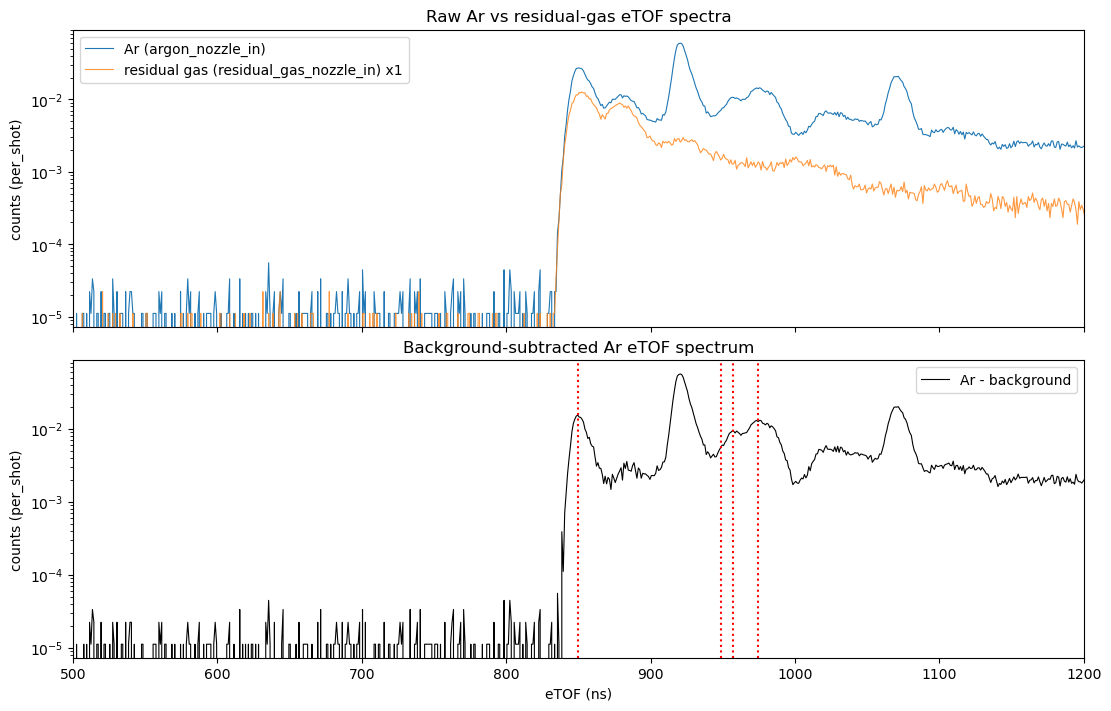

In [200]:
ar_sub = ar_spec - BG_SCALE * bg_spec

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7), sharex=True,
                               constrained_layout=True)
ax1.semilogy(tof_cent, ar_spec, lw=0.8, label=f"Ar ({NAME_AR})")
ax1.semilogy(tof_cent, BG_SCALE * bg_spec, lw=0.8, alpha=0.8,
         label=f"residual gas ({NAME_BG}) x{BG_SCALE:g}")
ax1.set_ylabel(f"counts ({NORMALISE})")
ax1.legend(); ax1.set_title("Raw Ar vs residual-gas eTOF spectra")

ax2.semilogy(tof_cent, ar_sub, lw=0.8, color="k", label="Ar - background")
ax2.axhline(0, color="r", lw=0.5)
ax2.set_xlabel("eTOF (ns)"); ax2.set_ylabel(f"counts ({NORMALISE})")
ax2.legend(); ax2.set_title("Background-subtracted Ar eTOF spectrum")

ax2.axvline(850, ls=':', c='r')
ax2.axvline(974, ls=':', c='r')
ax2.axvline(949, ls=':', c='r')
ax2.axvline(957, ls=':', c='r')
# ax2.axvline(974, ls=':', c='r')
ax2.axvline(4160, ls=':', c='r')
ax2.axvline(4750, ls=':', c='r')
ax2.axvline(1855, ls=':', c='r')
ax2.axvline(2300, ls=':', c='r')

ax2.set_xlim(500, 1200)
plt.show()


## 4. Match TOF peaks to known Argon lines (hν = 270 eV)

Because this is a single-energy measurement, we identify lines by their
**known static kinetic energies**, not by dispersion. The next cell builds
this reference table from `PHOTON_ENERGY_EV`.

**Photolines** — `KE = hν − BE`:

| line | level | BE (eV) | KE at 270 eV (eV) |
|------|-------|---------|-------------------|
| L1 | 2p₁/₂ | 250.6 | 19.4 |
| L3 | 2p₃/₂ | 248.4 | 21.6 |
| M1 | 3s    | 29.3  | 240.7 |
| M2 | 3p₁/₂ | 15.9  | 254.1 |
| M3 | 3p₃/₂ | 15.7  | 254.3 |

The M2/M3 (3p) pair is split by only 0.2 eV — expect a single unresolved
3p peak near 254 eV. L1/L3 (2p) are 2.2 eV apart at low KE (~20 eV), i.e.
slow electrons at long TOF that may or may not be resolved.

**Auger lines** — *fixed* KE (independent of hν) and **broad** multiplets:

| transition | approx KE (eV) |
|------------|----------------|
| L₂,₃–M₁M₁     | 148 |
| L₂,₃–M₁M₂,₃   | 180 |
| L₂,₃–M₂,₃M₂,₃ | 210 |

These are collections of peaks — use their centroids as soft anchors.

The retarding voltage (10 V) makes the drift energy `KE − 10`, which the
fit accounts for. Run the next cell to list candidate peaks, then fill in
`ASSIGNMENTS` as `(tof_peak_ns, line_name)` using names from the table.

In [206]:
# Reference line table, resolved from the photon energy.
# Photolines: KE = hv - BE. Auger: fixed literature KE (broad multiplets).
LINES = [
    {"name": "L2 (2p1/2)", "kind": "photo", "be": 250.6},
    {"name": "L3 (2p3/2)", "kind": "photo", "be": 248.4},
    {"name": "L3 (2p3/2)", "kind": "photo", "be": 248.4},
    {"name": "M1 (3s)",    "kind": "photo", "be": 29.24},
    {"name": "M2 (3p1/2)", "kind": "photo", "be": 15.9},
    {"name": "M3 (3p3/2)", "kind": "photo", "be": 15.7},
    {"name": "L23-M1M1_high",   "kind": "auger", "ke": 178.0, "broad": True},
    {"name": "L23-M1M1_low",   "kind": "auger", "ke": 148.0, "broad": True},
    {"name": "L23-M1M23",  "kind": "auger", "ke": 192.0, "broad": True},
    {"name": "L23-M23M23", "kind": "auger", "ke": 205.0, "broad": True},
]

# Resolve each line's born KE (before retardation) and print the table.
LINE_KE = {}
print(f"reference lines at hv = {PHOTON_ENERGY_EV} eV "
      f"(retarding {RETARDING_VOLTAGE_V} V):")
print(f"{'line':>12} {'kind':>6} {'KE (eV)':>9} {'KE-V drift':>11}")
for L in LINES:
    ke = PHOTON_ENERGY_EV - L["be"] if L["kind"] == "photo" else L["ke"]
    LINE_KE[L["name"]] = ke
    tag = "  (broad)" if L.get("broad") else ""
    print(f"{L['name']:>12} {L['kind']:>6} {ke:>9.1f} "
          f"{ke - RETARDING_VOLTAGE_V:>11.1f}{tag}")

# Suggest candidate peaks in the subtracted spectrum (tune prominence).

pk, props = find_peaks(ar_sub, prominence=np.nanmax(ar_sub) * 0.02)
order = np.argsort(props["prominences"])[::-1]
print()
print("candidate peaks (most prominent first):")
print(f"{'TOF (ns)':>10} {'counts':>12} {'prominence':>12}")
for i in order[:25]:
    print(f"{tof_cent[pk[i]]:>10.2f} {ar_sub[pk[i]]:>12.4g} "
          f"{props['prominences'][i]:>12.4g}")

# --- FILL IN after inspecting the spectrum ----------------------------
# Map each identified TOF peak to a line name from LINE_KE above.
# Slow (low-KE) lines have the LONGEST TOF; fast (high-KE) the shortest.
# Example (edit & uncomment):
ASSIGNMENTS = [
    (850.0, "M2 (3p1/2)"),    # ~254 eV, shortest TOF (3p, unresolved with M3)
    (882.0, "M1 (3s)"),       # ~241 eV
    # (1855.0, "L23-M23M23"),    # ~210 eV Auger
    (920.0, "L23-M23M23"),    # ~210 eV Auger
    (957.0, "L23-M1M23"),     # ~180 eV Auger
    (975.0, "L23-M1M1_high"),      # 
    (1079.0, "L23-M1M1_low"),      # ~148 eV Auger
    # (4160.0, "L3 (2p3/2)"),    # ~22 eV, long TOF
    # (4750.0, "L1 (2p1/2)"),    # ~19 eV, long TOF
    # (1860.0, "L3 (2p3/2)"),    # ~22 eV, long TOF
    # # (2015.0, "L3 (2p3/2)"),    # ~22 eV, long TOF
    # (1910.0, "L2 (2p1/2)"),    # ~19 eV, long TOF
]
# ASSIGNMENTS = []
assert len(ASSIGNMENTS) >= 2, (
    "need at least 2 (TOF, line) pairs to fit; 3+ recommended for a residual check"
)
for _t, _name in ASSIGNMENTS:
    if _name not in LINE_KE:
        raise KeyError(f"unknown line {_name!r}; choose from {list(LINE_KE)}")

reference lines at hv = 271.0 eV (retarding -32.01 V):
        line   kind   KE (eV)  KE-V drift
  L2 (2p1/2)  photo      20.4        52.4
  L3 (2p3/2)  photo      22.6        54.6
  L3 (2p3/2)  photo      22.6        54.6
     M1 (3s)  photo     241.8       273.8
  M2 (3p1/2)  photo     255.1       287.1
  M3 (3p3/2)  photo     255.3       287.3
L23-M1M1_high  auger     178.0       210.0  (broad)
L23-M1M1_low  auger     148.0       180.0  (broad)
   L23-M1M23  auger     192.0       224.0  (broad)
  L23-M23M23  auger     205.0       237.0  (broad)

candidate peaks (most prominent first):
  TOF (ns)       counts   prominence
    920.50        0.057        0.057
   1856.50       0.0319       0.0312
   1071.50      0.02025      0.01853
    849.50      0.01552      0.01404
    975.50      0.01318     0.009175
   2014.50      0.01408     0.008853
   2305.50      0.01003     0.006165
   1906.50      0.01111     0.003388
   1021.50      0.00592     0.002421
    883.50     0.003588     0.00155

linear estimate: t0 = 23.062 ns, b = 13994.822
fitted: t0 = 23.0620 ns, b = 13994.8218  ->  KE(t) = (b/(t-t0))^2 + -32.01
    M2 (3p1/2): KE=  255.1 eV  TOF=  850.00  pred=  848.99  d=+1.008 ns
       M1 (3s): KE=  241.8 eV  TOF=  882.00  pred=  868.88  d=+13.125 ns
    L23-M23M23: KE=  205.0 eV  TOF=  920.00  pred=  932.10  d=-12.104 ns
     L23-M1M23: KE=  192.0 eV  TOF=  957.00  pred=  958.11  d=-1.110 ns
  L23-M1M1_high: KE=  178.0 eV  TOF=  975.00  pred=  988.77  d=-13.774 ns
  L23-M1M1_low: KE=  148.0 eV  TOF= 1079.00  pred= 1066.15  d=+12.854 ns
RMS TOF residual: 10.614 ns


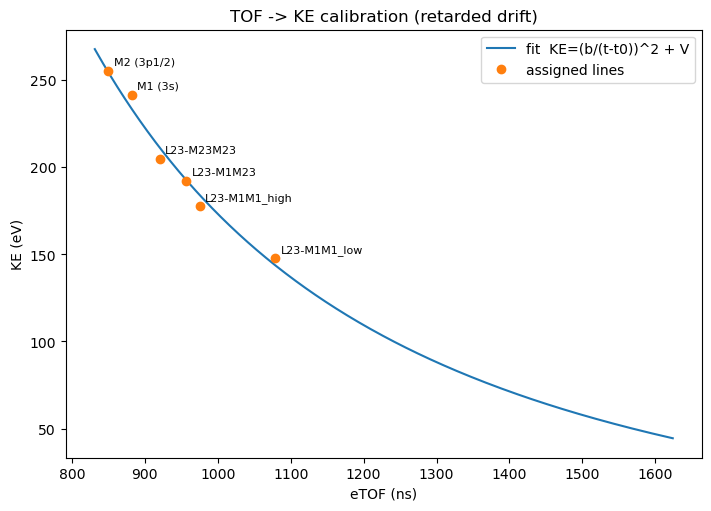

In [207]:
V = RETARDING_VOLTAGE_V

# Resolve assigned (TOF, born KE) and convert to drift energy KE - V.
t_pk    = np.array([t for t, _ in ASSIGNMENTS], dtype=np.float64)
ke_born = np.array([LINE_KE[name] for _, name in ASSIGNMENTS], dtype=np.float64)
labels  = [name for _, name in ASSIGNMENTS]
ke_drift = ke_born - V
if np.any(ke_drift <= 0):
    raise ValueError("a line has KE <= retarding voltage; it cannot reach the detector")

# Linear estimate: t = t0 + b * (KE-V)^(-1/2)  (slope = b, intercept = t0).
x = 1.0 / np.sqrt(ke_drift)
b_lin, t0_lin = np.polyfit(x, t_pk, 1)
print(f"linear estimate: t0 = {t0_lin:.3f} ns, b = {b_lin:.3f}")

def t_of_ke(ke_born, t0, b, v=V):
    """Forward model: TOF (ns) for a born kinetic energy KE (eV)."""
    return t0 + b / np.sqrt(ke_born - v)

# Nonlinear refine on the born-KE forward model.
(t0, b), _ = curve_fit(lambda k, t0, b: t_of_ke(k, t0, b),
                       # ke_born, t_pk, p0=(t0_lin, b_lin))
                       ke_born, t_pk, p0=(70, 10*CONV_FACTOR*0.77932))
# t0, b = 70, 10*CONV_FACTOR*0.77932

print(f"fitted: t0 = {t0:.4f} ns, b = {b:.4f}  ->  KE(t) = (b/(t-t0))^2 + {V:g}")

# Residuals at the calibration points.
t_pred = t_of_ke(ke_born, t0, b)
resid = t_pk - t_pred
for lbl, ke, t, tp, r in zip(labels, ke_born, t_pk, t_pred, resid):
    print(f"  {lbl:>12}: KE={ke:7.1f} eV  TOF={t:8.2f}  pred={tp:8.2f}  d={r:+.3f} ns")
rms = float(np.sqrt(np.mean(resid ** 2)))
print(f"RMS TOF residual: {rms:.3f} ns")

# Calibration curve over the assigned KE range.
fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
ke_grid = np.linspace(ke_born.min() * 0.3, ke_born.max() * 1.05, 400)
ax.plot(t_of_ke(ke_grid, t0, b), ke_grid, "-", label="fit  KE=(b/(t-t0))^2 + V")
ax.plot(t_pk, ke_born, "o", label="assigned lines")
for t, ke, lbl in zip(t_pk, ke_born, labels):
    ax.annotate(lbl, (t, ke), fontsize=8, xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("eTOF (ns)"); ax.set_ylabel("KE (eV)")
ax.legend(); ax.set_title("TOF -> KE calibration (retarded drift)")
plt.show()

In [208]:
def ke_of_t(t, t0, b, v=V):
    """Forward model: TOF (ns) for a born kinetic energy KE (eV)."""
    # return t0 + b / np.sqrt(ke_born - v)
    return((b/(t-t0))**2)+v

## 6. Apply the calibration and save

Plot the Argon spectrum on a KE axis. The axis is nonlinear, so divide the
per-TOF-bin counts by `|dKE/dt|` for a per-eV density (Jacobian
correction). Then persist the parameters (including the retarding voltage)
so every other post notebook loads the same calibration.

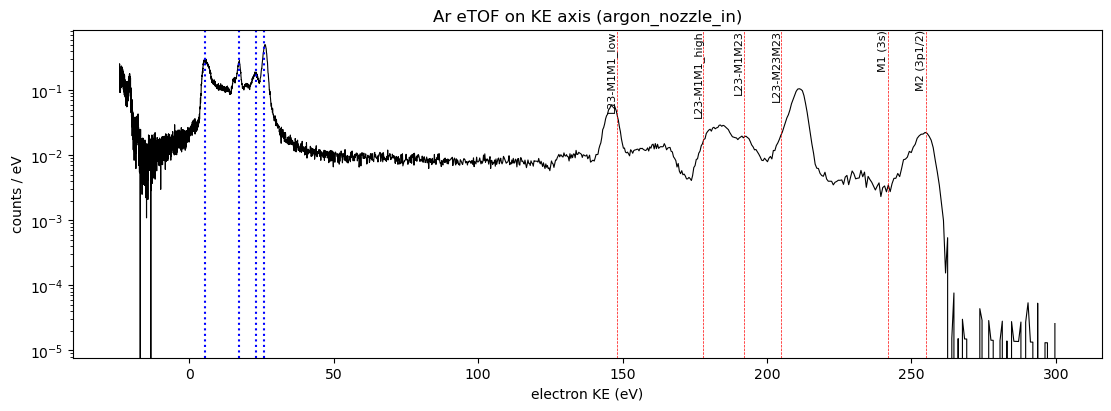

In [209]:
def tof_to_ke(t, t0=t0, b=b, v=V):
    """Calibrated born electron kinetic energy (eV) for a TOF (ns).

    KE(t) = (b / (t - t0))^2 + v, valid for t > t0; NaN otherwise. The +v
    term restores the energy removed by the retarding potential. dKE/dt is
    large at small drift energy, so KE resolution degrades for slow
    (long-TOF) electrons.
    """
    t = np.asarray(t, dtype=np.float64)
    return np.where(t > t0, (b / (t - t0)) ** 2 + v, np.nan)

# Convert the subtracted Ar spectrum onto a KE axis (Jacobian-corrected).
ke_axis = tof_to_ke(tof_cent)
dke_dt = np.gradient(ke_axis, tof_cent)
with np.errstate(invalid="ignore", divide="ignore"):
    spec_ke = ar_sub / np.abs(dke_dt)   # counts per eV

good = np.isfinite(ke_axis)
good = ke_axis<300
fig, ax = plt.subplots(figsize=(11, 4), constrained_layout=True)
ax.semilogy(ke_axis[good], spec_ke[good], lw=0.8, color="k")
for ke, lbl in zip(ke_born, labels):
    ax.axvline(ke, color="r", lw=0.5, ls="--")
    ax.annotate(lbl, (ke, ax.get_ylim()[1]), fontsize=8,
                rotation=90, va="top", ha="right")
ax.set_xlabel("electron KE (eV)"); ax.set_ylabel("counts / eV")
ax.set_title(f"Ar eTOF on KE axis ({NAME_AR})")

# Persist the calibration so every post notebook loads the same one.
calib_dir = Path(_REPO_ROOT) / "analysis" / "post" / "calibration"
calib_dir.mkdir(parents=True, exist_ok=True)
calib = {
    "model": "KE = (b / (t - t0))**2 + retarding_voltage_V",
    "t0_ns": float(t0),
    "b": float(b),
    "retarding_voltage_V": float(V),
    "photon_energy_eV": float(PHOTON_ENERGY_EV),
    "run_ar": int(RUN_AR),
    "run_bg": int(RUN_BG),
    "name_ar": NAME_AR,
    "name_bg": NAME_BG,
    "signal_bunch_range": list(SIGNAL_BUNCH_RANGE),
    "assignments": [[float(t), LINE_KE[name], name] for t, name in ASSIGNMENTS],
    "rms_tof_residual_ns": rms,
}
# calib_path = calib_dir / f"etof_tof_to_ke_{NAME_AR}.json"
# with open(calib_path, "w") as fh:
#     json.dump(calib, fh, indent=2)
# print(f"saved calibration -> {calib_path}")
# ax.axvline(ke_of_t(850, t0, b), ls=':', c='b')
# ax.axvline(ke_of_t(882, t0, b), ls=':', c='b')

# ax.axvline(ke_of_t(920, t0, b), ls=':', c='b')
# ax.axvline(ke_of_t(957, t0, b), ls=':', c='b')
# ax.axvline(ke_of_t(975, t0, b), ls=':', c='b')
# ax.axvline(ke_of_t(1070, t0, b), ls=':', c='b')


ax.axvline(ke_of_t(2310, t0, b), ls=':', c='b')
ax.axvline(ke_of_t(2015, t0, b), ls=':', c='b')
ax.axvline(ke_of_t(1910, t0, b), ls=':', c='b')
ax.axvline(ke_of_t(1860, t0, b), ls=':', c='b')

# ax.set_xlim(0,100)

plt.show()


In [210]:
ke_of_t(900, t0, b)

222.6712739908581

## 7. Validation

This is a single photon energy, so we cannot use the dispersive test
(refit at another hν). Instead:

- Check the **RMS TOF residual** is small versus the bin width and that no
  single line dominates it.
- Confirm the **Auger** lines land at their literature KE (148 / 180 /
  210 eV) — they are independent of hν, so a systematic offset there flags
  a wrong retarding voltage or t0.
- Confirm the **photolines** sit at `hν − BE` on the KE-axis plot.
- Use the leave-one-out cell below: drop each line, refit, predict it.
- If residuals are poor, treat the effective offset (retarding voltage +
  contact potentials) as a free parameter instead of fixing it at 10 V.

To reuse the calibration in another post notebook:

```python
import json, numpy as np
c = json.load(open("analysis/post/calibration/etof_tof_to_ke_argon_nozzle_in.json"))
tof_to_ke = lambda t: (c["b"] / (np.asarray(t) - c["t0_ns"]))**2 + c["retarding_voltage_V"]
```

> **TODO (TASKS.md backlog):** decide whether `tof_to_ke` should be
> promoted into `analysis/scripts/processing.py` (loading params from this
> JSON) so all post notebooks share one implementation.

In [55]:
# Leave-one-out: refit without each line and predict its TOF.
if _HAVE_SCIPY and len(ASSIGNMENTS) >= 3:
    print("leave-one-out TOF prediction:")
    for k in range(len(ASSIGNMENTS)):
        keep = [j for j in range(len(ASSIGNMENTS)) if j != k]
        (t0_k, b_k), _ = curve_fit(
            lambda kk, t0, b: t_of_ke(kk, t0, b),
            ke_born[keep], t_pk[keep], p0=(t0_lin, b_lin)
        )
        pred = t_of_ke(ke_born[k], t0_k, b_k)
        print(f"  {labels[k]:>12}: actual {t_pk[k]:8.2f}  predicted {pred:8.2f}  "
              f"d={t_pk[k] - pred:+.3f} ns")
else:
    print("need scipy and >=3 assignments for leave-one-out validation.")

leave-one-out TOF prediction:
    M2 (3p1/2): actual   850.00  predicted    -1.31  d=+851.305 ns
    L3 (2p3/2): actual  4160.00  predicted  4265.71  d=-105.712 ns
    L1 (2p1/2): actual  4750.00  predicted  4629.30  d=+120.700 ns
